1.

In [1]:
import pandas as pd

q1_data = pd.read_excel('q1_data.xlsx')
q2_data = pd.read_excel('q2_data.xlsx')
q3_data = pd.read_excel('q3_data.xlsx')
q4_data = pd.read_excel('q4_data.xlsx')

df = pd.concat([q1_data, q2_data, q3_data, q4_data], ignore_index=True)

df.head(4)

,age,salary,experience_years,weekly_study_hours,courses_completed,login_days_past30,membership,device,region,promo_opt_in,num_promo_emails_last3m,churn
0,NaN,35922993.0,15,4.7,5,23,basic,desktop,서울특별시,1,2,0
1,33.0,41803885.0,15,6.2,2,27,premium,desktop,경기도,0,3,0
2,41.0,45766391.0,20,4.6,0,12,basic,mobile,경기도,1,4,0
3,50.0,65761614.0,29,9.5,4,29,basic,desktop,대전광역시,1,14,0


2.

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='churn', ylabel='count'>

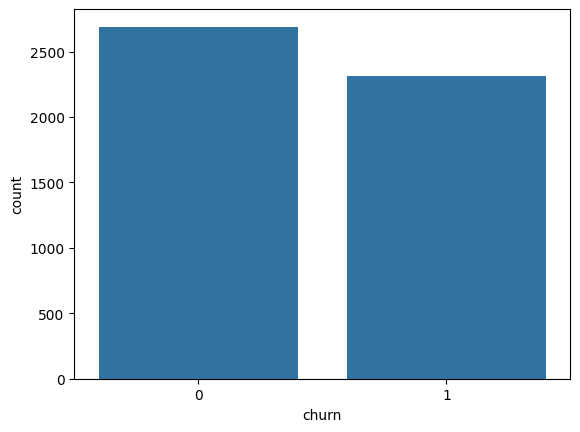

In [3]:
sns.countplot(data=df, x='churn')

In [4]:
df['churn'].head()

,churn
0,0
1,0
2,0
3,0
4,1


In [ ]:
분류

3.

In [5]:
pd.crosstab(df['membership'], df['churn'])

churn,0,1
membership,,
basic,1079,1966
premium,1216,253
vip,395,91


In [7]:
answer = (91 / (395+91)) * 100
print(round(answer, 2))

18.72


4.

In [8]:
df.isna().sum()

,0
age,909
salary,140
experience_years,0
weekly_study_hours,94
courses_completed,0
login_days_past30,0
membership,0
device,0
region,0
promo_opt_in,0


In [9]:
df['age'] = df['age'].fillna(df['age'].mean()).astype(int)
df['salary'] = df['salary'].fillna(df['salary'].median())
df['weekly_study_hours'] = df['weekly_study_hours'].fillna(0)

df.isna().sum()

,0
age,0
salary,0
experience_years,0
weekly_study_hours,0
courses_completed,0
login_days_past30,0
membership,0
device,0
region,0
promo_opt_in,0


5.

In [10]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
df_encoded = pd.get_dummies(df, columns=['membership', 'device', 'region'], drop_first=True)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   salary                   5000 non-null   float64
 2   experience_years         5000 non-null   int64  
 3   weekly_study_hours       5000 non-null   float64
 4   courses_completed        5000 non-null   int64  
 5   login_days_past30        5000 non-null   int64  
 6   promo_opt_in             5000 non-null   int64  
 7   num_promo_emails_last3m  5000 non-null   int64  
 8   churn                    5000 non-null   int64  
 9   membership_premium       5000 non-null   bool   
 10  membership_vip           5000 non-null   bool   
 11  device_mobile            5000 non-null   bool   
 12  device_tablet            5000 non-null   bool   
 13  region_광주광역시             5000 non-null   bool   
 14  region_대구광역시            

In [ ]:
20

6.

In [11]:
y = df_encoded['churn']
X = df_encoded.drop(columns=['churn'])

print(X.shape)
print(y.shape)

(5000, 19)
(5000,)


In [ ]:
19

7.

In [12]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from sklearn.model_selection import train_test_split

# 훈련 데이터셋(train)과 검증 데이터셋(valid) 분리(7:3 비율)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

8.

In [13]:
# (8-1) 여기에 코드의 오류를 정정하고 실행하세요.
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()

X_train_scaled = rs.fit_transform(X_train)
X_valid_scaled = rs.transform(X_valid)

max_val = np.max(X_valid_scaled)
print(round(max_val, 0))

4.0


In [ ]:
4

9.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr_model = LogisticRegression(random_state=42, C=1.0)
rf_model = RandomForestClassifier(random_state=42, max_depth=5)
xgb_model = XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')

lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

10.

In [15]:
from sklearn.metrics import f1_score

y_pred_lr = lr_model.predict(X_valid_scaled)
y_pred_rf = rf_model.predict(X_valid_scaled)
y_pred_xgb = xgb_model.predict(X_valid_scaled)

print('F1 Score')
print('LR :', round(f1_score(y_valid, y_pred_lr), 5))
print('RF :', round(f1_score(y_valid, y_pred_rf), 5))
print('XGB :', round(f1_score(y_valid, y_pred_xgb), 5))

F1 Score
LR : 0.88604
RF : 0.99056
XGB : 0.99496


In [ ]:
XGBClassifier

In [ ]:
0.99496

11.

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(100)

In [18]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
# 이미지 토폴로지에 기반한 모델 설계
model = Sequential([
    Dense(units=32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(units=8, activation='relu'),

    # 출력층
    Dense(units=1, activation='sigmoid')
])

dl_model = model

# 설계 결과 확인
dl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

12.

In [19]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Callback 설정
es = EarlyStopping(monitor='val_loss', patience=10)
mc = ModelCheckpoint(filepath='best_churn_model.keras',
                     monitor='val_accuracy',
                     save_best_only=True)

# 2. 모델 컴파일
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

13.

In [20]:
callbacks = [es, mc]

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(X_valid_scaled, y_valid), callbacks=callbacks)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5857 - loss: 0.6544 - val_accuracy: 0.7113 - val_loss: 0.5870
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7240 - loss: 0.5674 - val_accuracy: 0.8227 - val_loss: 0.4883
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.4521 - val_accuracy: 0.8740 - val_loss: 0.3316
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8480 - loss: 0.3593 - val_accuracy: 0.8953 - val_loss: 0.2607
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8669 - loss: 0.3172 - val_accuracy: 0.9047 - val_loss: 0.2338
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8760 - loss: 0.2909 - val_accuracy: 0.9093 - val_loss: 0.2187
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8857 - loss: 0.2657 - val_accuracy: 0.9207 - val_loss: 0.1956
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8897 - loss: 0.2472 - val_acc

In [ ]:
32

14.

In [21]:
# 이 코드를 먼저 실행하시오.
from tensorflow.keras.models import load_model
import numpy as np
sample_data = np.array([[1.0, 0.97, 1.27, -0.19, -1.0, -1.15, 0.0, -0.75, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]])

In [22]:
best_model = load_model('best_churn_model.keras')

pred = best_model.predict(sample_data)

print(np.where(pred >= 0.5, 1, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[[0]]


In [ ]:
유지